# 02 — EDA: Fall Detection Datasets

**Tarea:** B1 — Exploración de MobiAct v2 + SisFall

Objetivos:
- Visualizar señales de caídas vs ADL
- Distribución temporal: impacto (pico SVM) → inmovilidad post-caída
- Identificar umbral SVM empírico para la cascada
- Diferencia de señal: jóvenes (MobiAct/SisFall SA) vs ancianos (SisFall SE)
- Desbalanceo ADL/caídas — motivar SMOTE + class_weight

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

sys.path.insert(0, str(Path('..').resolve()))
from src.preprocessing.windowing import (
    resample, compute_svm, detect_impact_peaks,
    extract_fall_window, butterworth_lowpass, normalize_subject
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_RAW = Path('../data/raw')
DATA_PROC = Path('../data/processed')
DATA_PROC.mkdir(parents=True, exist_ok=True)

## 1. Dataset Inventory

In [2]:
for ds in ['MobiAct', 'SisFall']:
    p = DATA_RAW / ds
    if p.exists():
        files = list(p.rglob('*.csv')) + list(p.rglob('*.txt'))
        print(f"{ds}: {len(files)} files found")
    else:
        print(f"{ds}: NOT FOUND — download to data/raw/{ds}/")

MobiAct: NOT FOUND — download to data/raw/MobiAct/
SisFall: NOT FOUND — download to data/raw/SisFall/


## 2. SisFall — Loader

**Formato oficial (README):**
- 9 columnas en bits, separadas por coma, 200 Hz
- Col 0-2: ADXL345 accel xyz — ±16g, 13 bits → factor `32/8192`
- Col 3-5: ITG3200 gyro xyz — ±2000 °/s, 16 bits → factor `4000/65536`
- Col 6-8: MMA8451Q accel xyz — ±8g, 14 bits (usamos ADXL345 como primario)
- Ficheros: `<CODE>_<SUBJECT>_R<TRIAL>.txt` dentro de carpetas SA01–SE15
- F* = caída, D* = ADL
- SA* = adulto joven (19-30), SE* = anciano (60-75)

In [3]:
import io

SISFALL_DIR = DATA_RAW / 'SisFall_dataset'
SISFALL_HZ = 200

# Conversion factors (bits → physical units)
ADXL345_FACTOR = (2 * 16) / (2 ** 13)   # ±16g, 13-bit → g
ITG3200_FACTOR  = (2 * 2000) / (2 ** 16) # ±2000°/s, 16-bit → °/s


def load_sisfall_file(filepath: Path) -> np.ndarray | None:
    """Load SisFall .txt and convert bits → [ax,ay,az,gx,gy,gz] at 200 Hz.

    Format: 9 comma-separated values per line with trailing semicolon.
    Returns (N, 6) float32 array or None on error.
    """
    try:
        text = filepath.read_text()
        text = text.replace(';', '')  # strip trailing semicolons
        raw = np.genfromtxt(io.StringIO(text), delimiter=',', dtype=np.float32)
    except Exception:
        return None
    if raw.ndim != 2 or raw.shape[1] < 6:
        return None
    accel = raw[:, 0:3] * ADXL345_FACTOR
    gyro  = raw[:, 3:6] * ITG3200_FACTOR
    return np.concatenate([accel, gyro], axis=1).astype(np.float32)


def parse_sisfall_filename(filepath: Path) -> dict:
    """Parse SisFall filename: F01_SA01_R01.txt → {code, is_fall, subject, age_group, trial}."""
    stem = filepath.stem
    parts = stem.split('_')
    if len(parts) < 3:
        return {}
    code = parts[0]
    subject = parts[1]
    trial = parts[2]
    return {
        'code': code,
        'is_fall': code.startswith('F'),
        'subject': subject,
        'age_group': 'elderly' if subject.startswith('SE') else 'young_adult',
        'trial': trial,
    }


def load_sisfall_dataset(base_dir: Path) -> pd.DataFrame:
    """Load all SisFall files. Returns DataFrame with sensor data + metadata."""
    records = []
    for subj_dir in sorted(base_dir.iterdir()):
        if not subj_dir.is_dir():
            continue
        for txt_file in sorted(subj_dir.glob('*.txt')):
            meta = parse_sisfall_filename(txt_file)
            if not meta:
                continue
            data = load_sisfall_file(txt_file)
            if data is None:
                continue
            data_50 = resample(data, orig_hz=SISFALL_HZ, target_hz=50)
            records.append({
                'data': data_50,
                'is_fall': meta['is_fall'],
                'code': meta['code'],
                'subject': meta['subject'],
                'age_group': meta['age_group'],
                'trial': meta['trial'],
                'n_samples': len(data_50),
            })
    return pd.DataFrame(records)


if SISFALL_DIR.exists():
    print("Loading SisFall...")
    df_sis = load_sisfall_dataset(SISFALL_DIR)
    print(f"Loaded {len(df_sis)} recordings")
    print(f"Falls:  {df_sis['is_fall'].sum()} | ADL: {(~df_sis['is_fall']).sum()}")
    print(f"Young adults (SA): {(df_sis['age_group']=='young_adult').sum()} recordings")
    print(f"Elderly (SE):      {(df_sis['age_group']=='elderly').sum()} recordings")
    print(f"Subjects: {df_sis['subject'].nunique()} unique")
    print(f"Fall codes: {sorted(df_sis[df_sis['is_fall']]['code'].unique())}")
    print(f"ADL codes:  {sorted(df_sis[~df_sis['is_fall']]['code'].unique())}")
else:
    print(f"SisFall NOT FOUND at {SISFALL_DIR}")
    df_sis = pd.DataFrame()


Loading SisFall...


Loaded 4505 recordings
Falls:  1798 | ADL: 2707
Young adults (SA): 3532 recordings
Elderly (SE):      973 recordings
Subjects: 38 unique
Fall codes: ['F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15']
ADL codes:  ['D01', 'D02', 'D03', 'D04', 'D05', 'D06', 'D07', 'D08', 'D09', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'D16', 'D17', 'D18', 'D19']


## 3. SisFall — SVM Visualization: Falls vs ADL

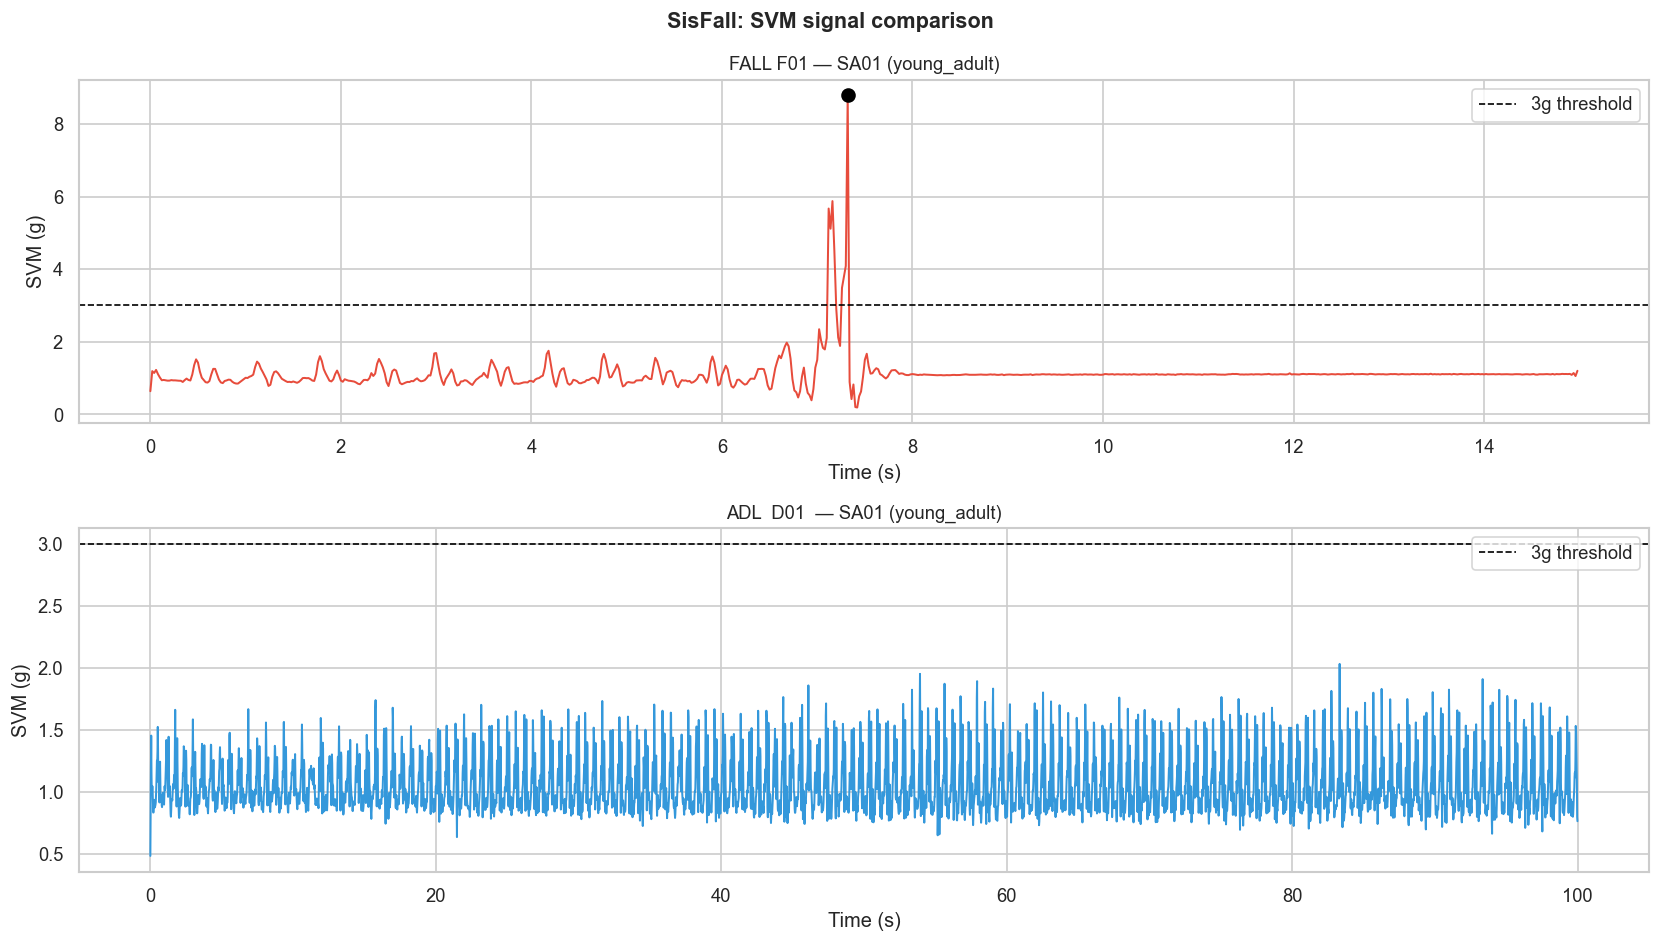

In [4]:
if len(df_sis) > 0:
    # Pick one example fall and one ADL
    fall_ex = df_sis[df_sis['is_fall']].iloc[0]
    adl_ex  = df_sis[~df_sis['is_fall']].iloc[0]

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    for ax, rec, title in zip(axes,
                              [fall_ex, adl_ex],
                              [f"FALL {fall_ex['code']} — {fall_ex['subject']} ({fall_ex['age_group']})",
                               f"ADL  {adl_ex['code']}  — {adl_ex['subject']} ({adl_ex['age_group']})"]):
        data = rec['data']
        svm = compute_svm(data[:, :3])
        t = np.arange(len(svm)) / 50.0
        color = '#e74c3c' if rec['is_fall'] else '#3498db'
        ax.plot(t, svm, color=color, linewidth=1.2)
        ax.axhline(y=3.0, color='black', linestyle='--', linewidth=1, label='3g threshold')
        peaks = detect_impact_peaks(svm, threshold_g=3.0)
        if len(peaks) > 0:
            ax.scatter(t[peaks], svm[peaks], color='black', zorder=5, s=60)
        ax.set_title(title, fontsize=11)
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('SVM (g)')
        ax.legend()
    plt.suptitle('SisFall: SVM signal comparison', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../data/processed/sisfall_svm_example.png', bbox_inches='tight')
    plt.show()

## 4. SisFall — Young Adult vs Elderly Signal Difference

Young adult falls — median SVM peak: 5.38g
Elderly falls     — median SVM peak: 3.54g
→ Elderly falls produce LOWER SVM peaks
→ Threshold may need to be lower for 65+ segment


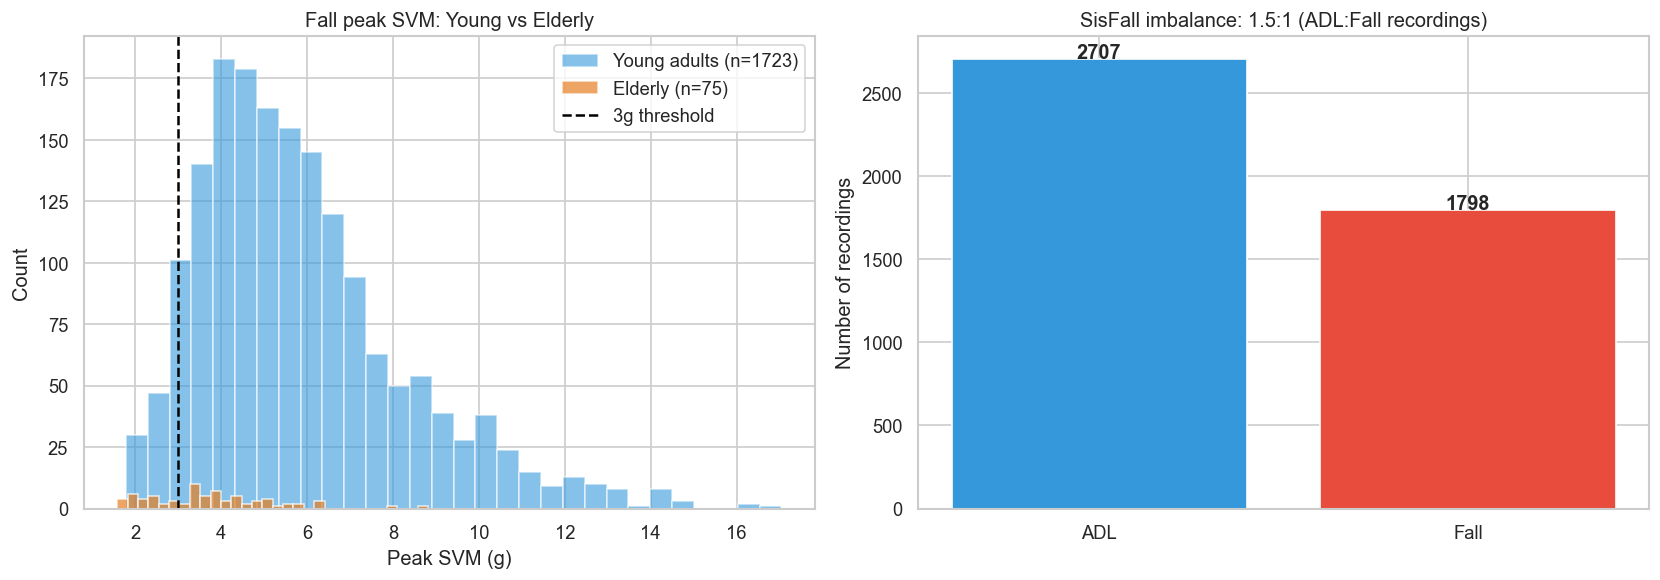

In [5]:
if len(df_sis) > 0:
    # Peak SVM per recording, split by age group and fall/ADL
    peak_data = []
    for _, row in df_sis.iterrows():
        svm = compute_svm(row['data'][:, :3])
        peak_data.append({
            'peak_svm': float(svm.max()),
            'is_fall': row['is_fall'],
            'age_group': row['age_group'],
            'code': row['code'],
        })
    df_peaks = pd.DataFrame(peak_data)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Falls only: young vs elderly peak SVM distribution
    falls_young   = df_peaks[(df_peaks['is_fall']) & (df_peaks['age_group'] == 'young_adult')]['peak_svm']
    falls_elderly = df_peaks[(df_peaks['is_fall']) & (df_peaks['age_group'] == 'elderly')]['peak_svm']

    axes[0].hist(falls_young,   bins=30, alpha=0.6, color='#3498db', label=f'Young adults (n={len(falls_young)})')
    axes[0].hist(falls_elderly, bins=30, alpha=0.7, color='#e67e22', label=f'Elderly (n={len(falls_elderly)})')
    axes[0].axvline(x=3.0, color='black', linestyle='--', label='3g threshold')
    axes[0].set_title('Fall peak SVM: Young vs Elderly')
    axes[0].set_xlabel('Peak SVM (g)')
    axes[0].set_ylabel('Count')
    axes[0].legend()

    if len(falls_young) > 0 and len(falls_elderly) > 0:
        print(f"Young adult falls — median SVM peak: {falls_young.median():.2f}g")
        print(f"Elderly falls     — median SVM peak: {falls_elderly.median():.2f}g")
        print(f"→ Elderly falls produce {'LOWER' if falls_elderly.median() < falls_young.median() else 'HIGHER'} SVM peaks")
        print(f"→ Threshold may need to be lower for 65+ segment")

    # Fall vs ADL imbalance
    fall_count = df_peaks['is_fall'].sum()
    adl_count  = (~df_peaks['is_fall']).sum()
    axes[1].bar(['ADL', 'Fall'], [adl_count, fall_count], color=['#3498db', '#e74c3c'])
    axes[1].set_title(f'SisFall imbalance: {adl_count/fall_count:.1f}:1 (ADL:Fall recordings)')
    axes[1].set_ylabel('Number of recordings')
    for i, v in enumerate([adl_count, fall_count]):
        axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig('../data/processed/sisfall_young_vs_elderly.png', bbox_inches='tight')
    plt.show()

## 5. SisFall — All 15 Fall Types: SVM Patterns

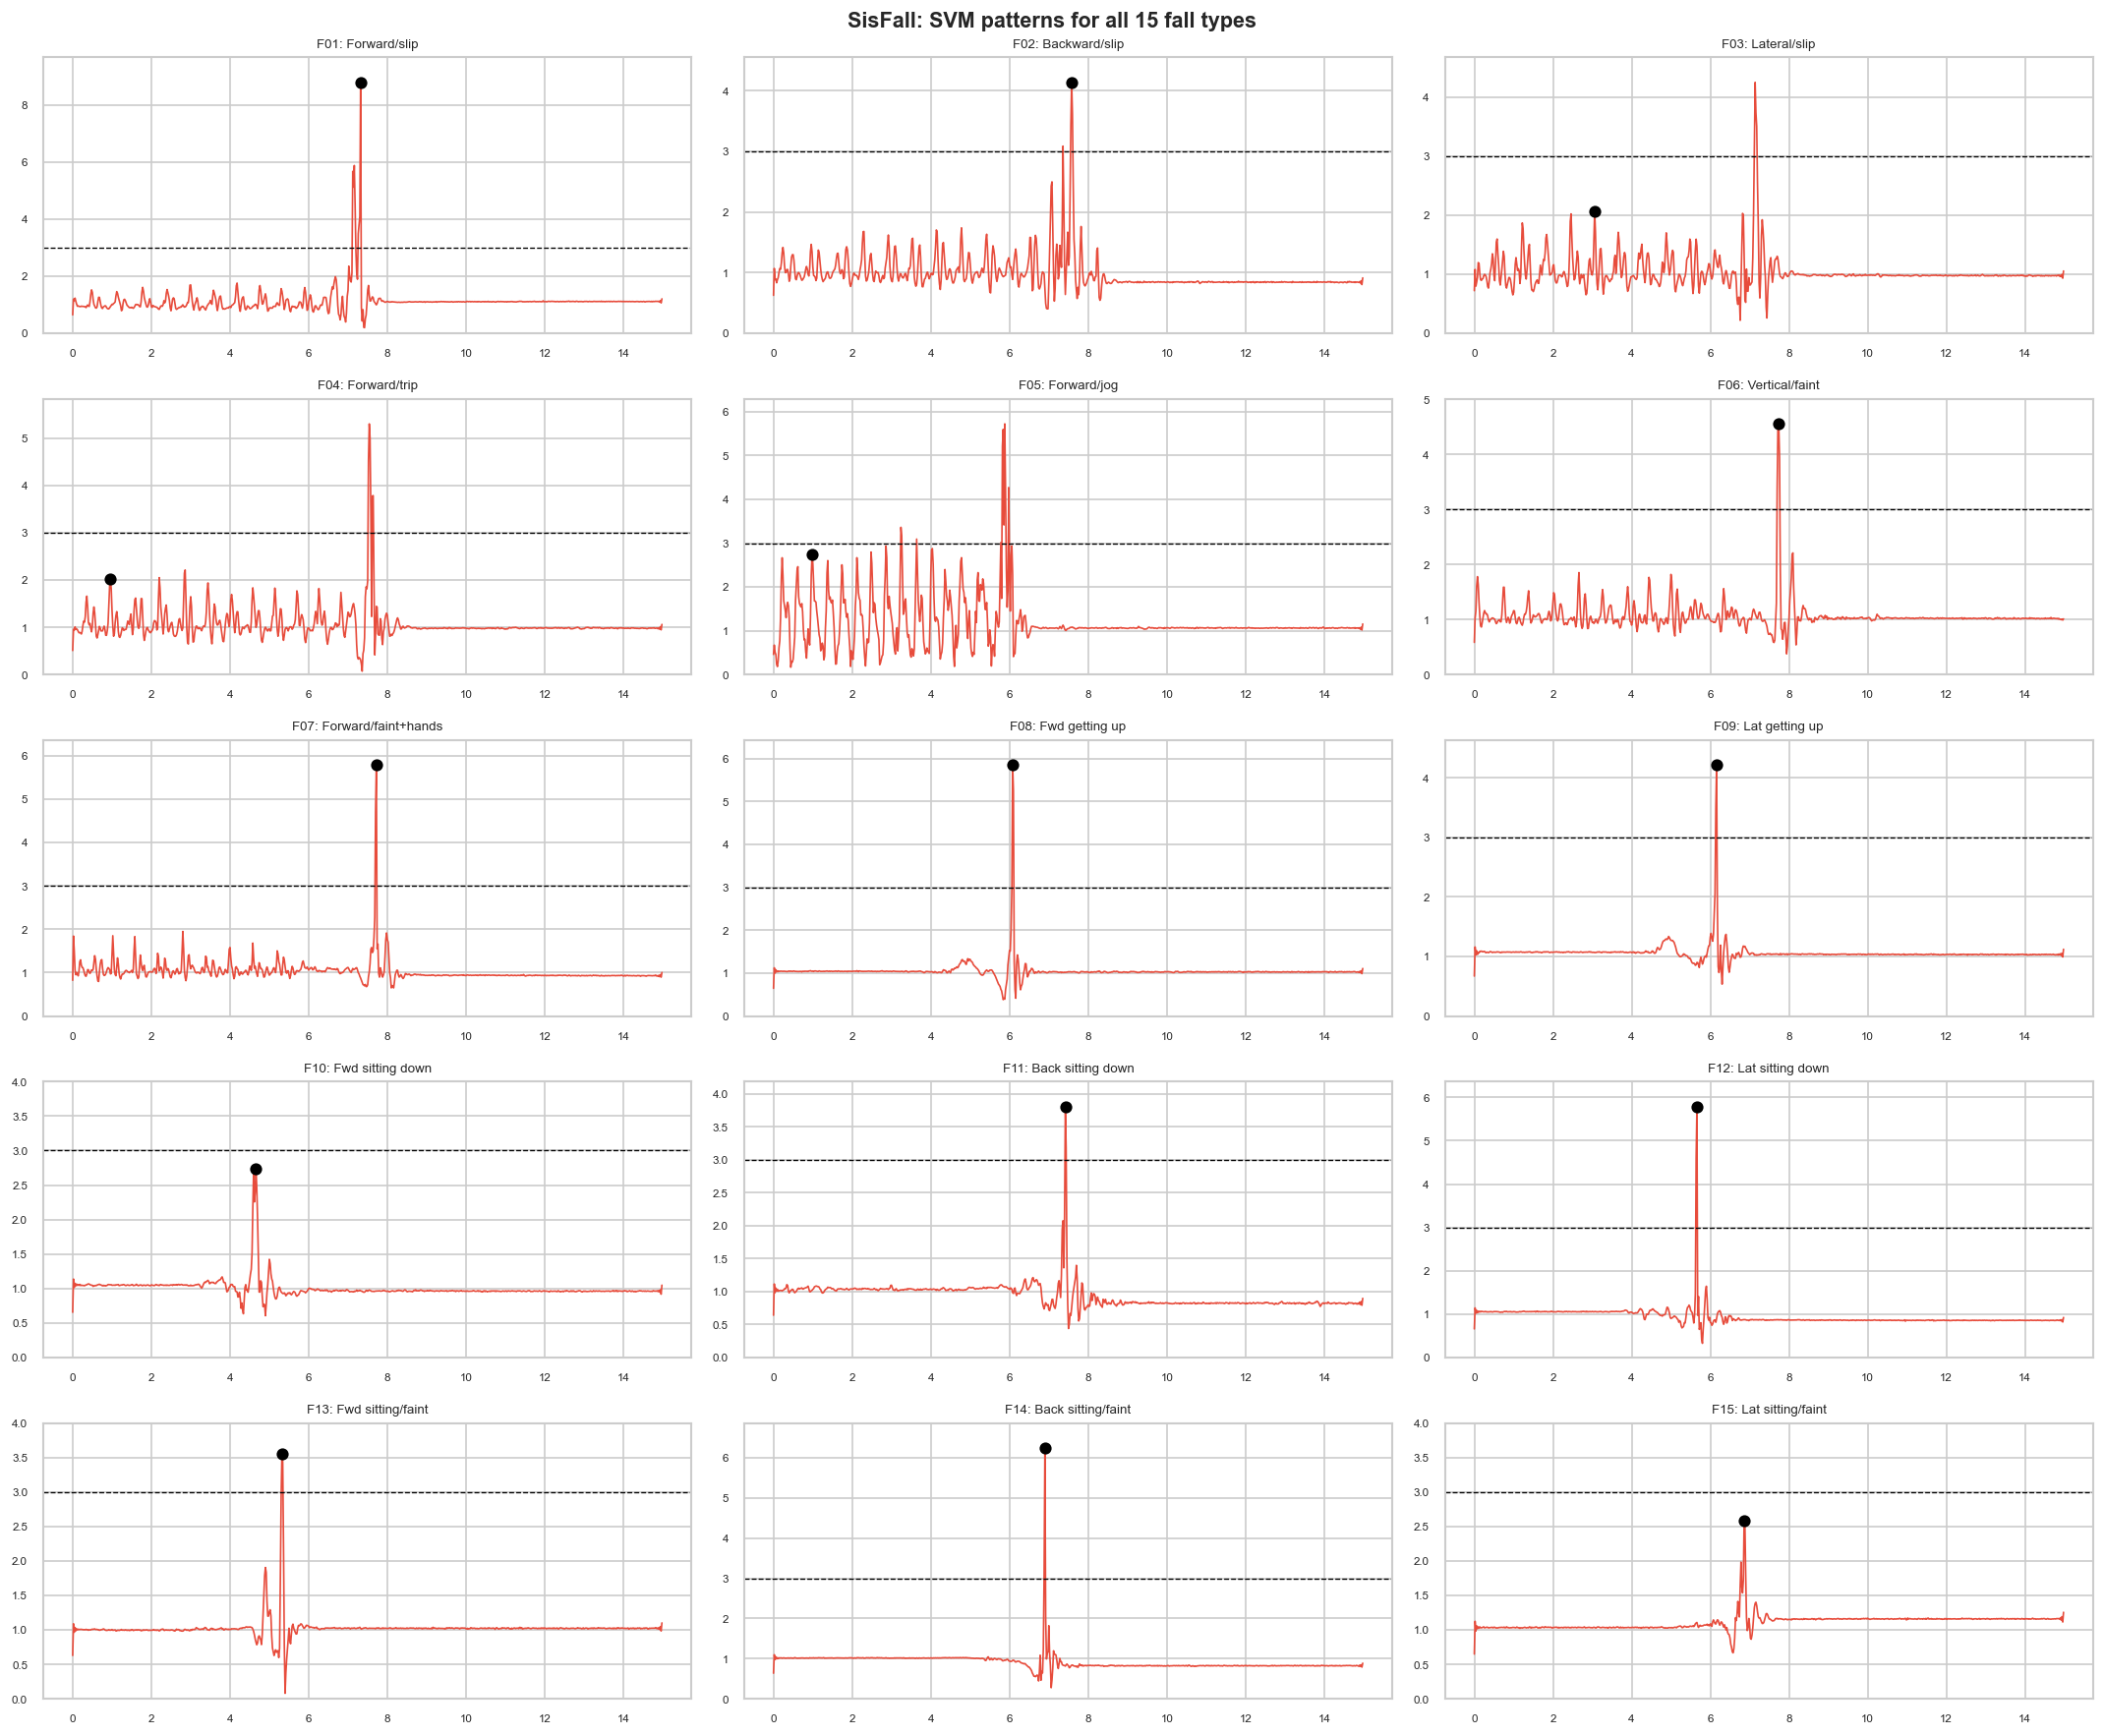

In [6]:
FALL_DESCRIPTIONS = {
    'F01': 'Forward/slip', 'F02': 'Backward/slip', 'F03': 'Lateral/slip',
    'F04': 'Forward/trip', 'F05': 'Forward/jog', 'F06': 'Vertical/faint',
    'F07': 'Forward/faint+hands', 'F08': 'Fwd getting up', 'F09': 'Lat getting up',
    'F10': 'Fwd sitting down', 'F11': 'Back sitting down', 'F12': 'Lat sitting down',
    'F13': 'Fwd sitting/faint', 'F14': 'Back sitting/faint', 'F15': 'Lat sitting/faint',
}

if len(df_sis) > 0:
    fall_codes = sorted(df_sis[df_sis['is_fall']]['code'].unique())
    n_cols = 3
    n_rows = (len(fall_codes) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
    axes = axes.flatten()

    for i, code in enumerate(fall_codes):
        subset = df_sis[(df_sis['is_fall']) & (df_sis['code'] == code)]
        if len(subset) == 0:
            continue
        # Use first young adult trial
        young = subset[subset['age_group'] == 'young_adult']
        rec = young.iloc[0] if len(young) > 0 else subset.iloc[0]
        svm = compute_svm(rec['data'][:, :3])
        t = np.arange(len(svm)) / 50.0
        axes[i].plot(t, svm, color='#e74c3c', linewidth=1)
        axes[i].axhline(y=3.0, color='black', linestyle='--', linewidth=0.8)
        peaks = detect_impact_peaks(svm, threshold_g=2.0)
        if len(peaks) > 0:
            axes[i].scatter(t[peaks[:1]], svm[peaks[:1]], color='black', s=40, zorder=5)
        axes[i].set_title(f'{code}: {FALL_DESCRIPTIONS.get(code, code)}', fontsize=8)
        axes[i].set_ylim(0, max(svm.max() * 1.1, 4))
        axes[i].tick_params(labelsize=7)

    for j in range(len(fall_codes), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('SisFall: SVM patterns for all 15 fall types', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../data/processed/sisfall_all_fall_types.png', bbox_inches='tight')
    plt.show()

## 6. Empirical SVM Threshold Analysis (SisFall)

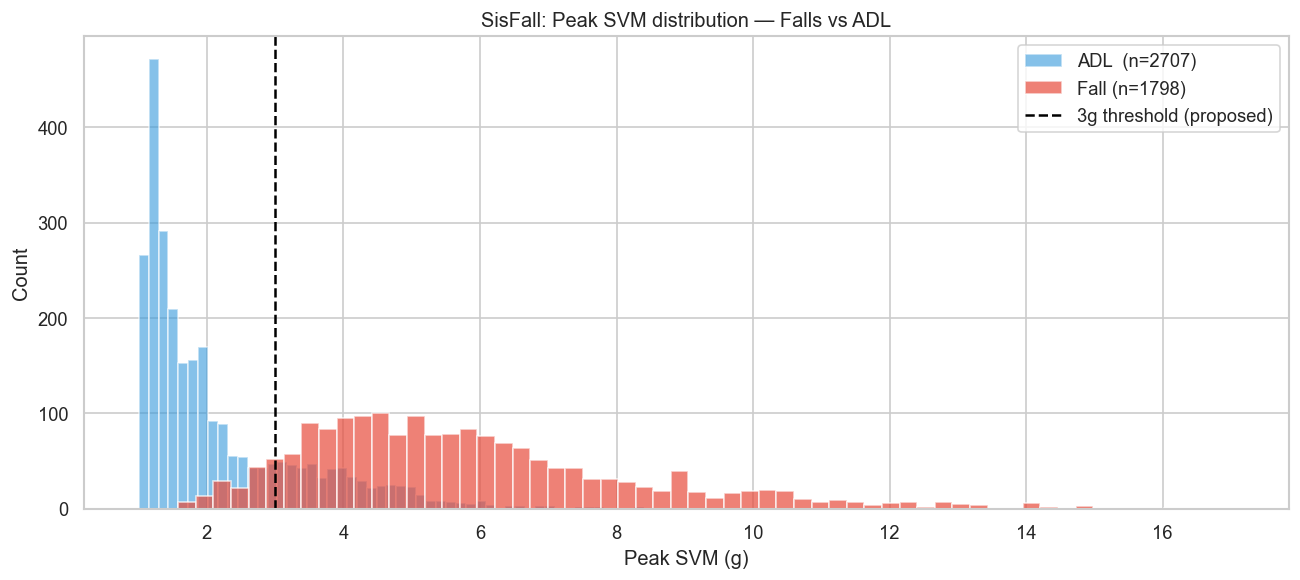


=== SVM Threshold Analysis ===
Fall peak SVM — median: 5.29g  |  5th pct: 2.75g
ADL  peak SVM — median: 1.70g  |  95th pct: 4.78g
Separation margin: -2.03g  (OVERLAP — lower threshold needed)

→ Conservative threshold for 65+ (catch all falls): 2.75g
→ Default threshold: 3.0g


In [7]:
if len(df_sis) > 0:
    peak_falls = df_peaks[df_peaks['is_fall']]['peak_svm'].values
    peak_adls  = df_peaks[~df_peaks['is_fall']]['peak_svm'].values

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.hist(peak_adls,  bins=60, alpha=0.6, color='#3498db', label=f'ADL  (n={len(peak_adls)})')
    ax.hist(peak_falls, bins=60, alpha=0.7, color='#e74c3c', label=f'Fall (n={len(peak_falls)})')
    ax.axvline(x=3.0, color='black', linestyle='--', linewidth=1.5, label='3g threshold (proposed)')
    ax.set_xlabel('Peak SVM (g)')
    ax.set_ylabel('Count')
    ax.set_title('SisFall: Peak SVM distribution — Falls vs ADL')
    ax.legend()
    plt.tight_layout()
    plt.savefig('../data/processed/sisfall_peak_svm_hist.png', bbox_inches='tight')
    plt.show()

    print("\n=== SVM Threshold Analysis ===")
    print(f"Fall peak SVM — median: {np.median(peak_falls):.2f}g  |  5th pct: {np.percentile(peak_falls, 5):.2f}g")
    print(f"ADL  peak SVM — median: {np.median(peak_adls):.2f}g  |  95th pct: {np.percentile(peak_adls, 95):.2f}g")
    sep = np.percentile(peak_falls, 5) - np.percentile(peak_adls, 95)
    print(f"Separation margin: {sep:.2f}g  ({'CLEAR' if sep > 0 else 'OVERLAP — lower threshold needed'})")
    print(f"\n→ Conservative threshold for 65+ (catch all falls): {np.percentile(peak_falls, 5):.2f}g")
    print(f"→ Default threshold: 3.0g")

## 7. MobiAct v2 — Loader (if available)

In [8]:
MOBIACT_DIR = DATA_RAW / 'MobiAct'
MOBIACT_HZ = 87
FALL_LABELS_MOBIACT = ['FOL', 'BSC', 'SDL', 'SIS']


def load_mobiact_dataset(base_dir: Path) -> pd.DataFrame:
    """Load MobiAct v2. Expects subfolders named by label (FOL/, WAL/, etc.)."""
    all_dfs = []
    for label_dir in sorted(base_dir.iterdir()):
        if not label_dir.is_dir():
            continue
        label = label_dir.name
        for f in sorted(label_dir.glob('*.csv')):
            try:
                df = pd.read_csv(f, comment='#')
                df.columns = [c.strip().lower() for c in df.columns]
                df['label'] = label
                df['subject_id'] = f.stem.split('_')[1] if '_' in f.stem else f.stem
                all_dfs.append(df)
            except Exception:
                pass
    return pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()


if MOBIACT_DIR.exists():
    print("Loading MobiAct...")
    df_mobiact = load_mobiact_dataset(MOBIACT_DIR)
    print(f"Loaded: {len(df_mobiact):,} rows")
    print(df_mobiact['label'].value_counts())
else:
    print("MobiAct not available — waiting for dataset access email")
    df_mobiact = pd.DataFrame()

MobiAct not available — waiting for dataset access email


## 8. Combined Summary

In [9]:
print("=" * 60)
print("EDA Summary — Fall Detection Datasets")
print("=" * 60)

if len(df_sis) > 0:
    fall_count = df_sis['is_fall'].sum()
    adl_count  = (~df_sis['is_fall']).sum()
    elderly_falls = df_sis[(df_sis['is_fall']) & (df_sis['age_group']=='elderly')]
    print(f"\nSisFall:")
    print(f"  {len(df_sis['subject'].unique())} subjects ({(df_sis['age_group']=='elderly').sum() // max(1, df_sis[df_sis['age_group']=='elderly']['subject'].nunique())} elderly unique)")
    print(f"  {fall_count} fall recordings | {adl_count} ADL recordings")
    print(f"  15 fall types, 19 ADL types")
    print(f"  Elderly subjects: {df_sis[df_sis['age_group']=='elderly']['subject'].nunique()} (SE01-SE15)")
    print(f"  → Note: elderly only did ADL (except SE06 Judo expert who also did falls)")

print(f"\nCascade design (confirmed from EDA):")
print(f"  Stage 1: SVM > 3.0g → trigger CNN (conservative) or adjust for 65+ segment")
print(f"  Stage 2: CNN sigmoid > threshold")
print(f"  Stage 3: 30s post-fall immobility check")

print(f"\nNext step: run notebook 04_fall_detection.ipynb → train CNN → export TFLite")

EDA Summary — Fall Detection Datasets

SisFall:
  38 subjects (64 elderly unique)
  1798 fall recordings | 2707 ADL recordings
  15 fall types, 19 ADL types
  Elderly subjects: 15 (SE01-SE15)
  → Note: elderly only did ADL (except SE06 Judo expert who also did falls)

Cascade design (confirmed from EDA):
  Stage 1: SVM > 3.0g → trigger CNN (conservative) or adjust for 65+ segment
  Stage 2: CNN sigmoid > threshold
  Stage 3: 30s post-fall immobility check

Next step: run notebook 04_fall_detection.ipynb → train CNN → export TFLite
